In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries imported!')

Libraries imported!


In [30]:
X_train = pd.read_csv(r'C:\Users\Madih\OneDrive\Documents\aicw\car_price_prediction\data\X_train.csv')
X_test  = pd.read_csv(r'C:\Users\Madih\OneDrive\Documents\aicw\car_price_prediction\data\X_test.csv')

# y_train / y_test are in LOG scale — model trains on these
y_train = pd.read_csv(r'C:\Users\Madih\OneDrive\Documents\aicw\car_price_prediction\data\y_train.csv').squeeze()
y_test  = pd.read_csv(r'C:\Users\Madih\OneDrive\Documents\aicw\car_price_prediction\data\y_test.csv').squeeze()

# y_orig_test is in original INR scale — we evaluate on this
y_orig_test = pd.read_csv(r'C:\Users\Madih\OneDrive\Documents\aicw\car_price_prediction\data\y_orig_test.csv').squeeze()

print(f'X_train shape      : {X_train.shape}')
print(f'y_train (log scale): min={y_train.min():.2f}, max={y_train.max():.2f}')
print(f'y_orig_test (INR)  : min=₹{y_orig_test.min():,}, max=₹{y_orig_test.max():,}')

X_train shape      : (580, 31)
y_train (log scale): min=10.31, max=14.95
y_orig_test (INR)  : min=₹35,000, max=₹2,800,000


In [3]:
y_train

,log_price
0,12.971540
1,13.629181
2,11.407576
3,12.873902
4,12.535376
...,...
575,12.765688
576,12.524526
577,12.409009
578,11.652687


In [4]:
def evaluate_model(model_name,y_true_inr,y_predicted_log):
    y_pred_inr= np.exp(y_predicted_log)
    mae= mean_absolute_error(y_true_inr,y_pred_inr)
    mse= mean_squared_error(y_true_inr,y_pred_inr)
    rmse=np.sqrt(mse)
    r2= r2_score(y_true_inr,y_pred_inr)
    print(f'the MAE is {mae}')
    print(f'the mse is {mse}')
    print(f'the rmse is {rmse}')
    print(f'the r2 score is {r2}')

In [5]:
def evaluate_model(model_name, y_true_inr, y_predicted_log):
    """
    Evaluate model performance in original INR scale.

    Parameters
    ----------
    model_name     : str   — name for display
    y_true_inr     : array — actual prices in INR
    y_predicted_log: array — model predictions in log scale

    Returns
    -------
    dict with MAE, MSE, RMSE, R2 (all in INR scale)
    """
    # Step 1: Convert log predictions back to INR
    y_pred_inr = np.exp(y_predicted_log)

    # Step 2: Compute metrics on INR scale
    mae  = mean_absolute_error(y_true_inr, y_pred_inr)
    mse  = mean_squared_error(y_true_inr, y_pred_inr)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true_inr, y_pred_inr)

    print(f'\n📊 {model_name}')
    print('-' * 50)
    print(f'  MAE  : ₹{mae:>10,.0f}  (average absolute error in INR)')
    print(f'  RMSE : ₹{rmse:>10,.0f}  (penalises large errors more)')
    print(f'  R²   : {r2:>10.4f}  ({r2*100:.1f}% of price variance explained)')
    print('-' * 50)

    return {'Model': model_name, 'MAE': int(mae), 'RMSE': int(rmse), 'R2': round(r2, 4)}


all_results = []
print('Evaluation function ready.')

Evaluation function ready.


NameError: name 'df' is not defined

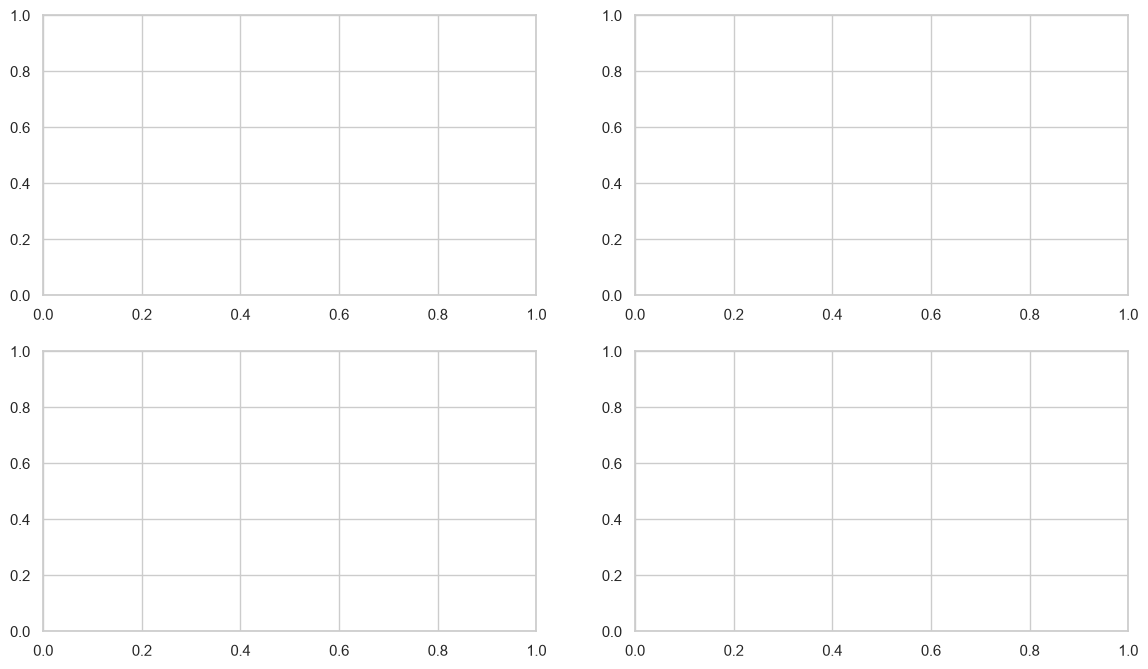

In [31]:
# Visualize the problem: raw Price vs log(Price)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw price histogram
axes[0, 0].hist(df['Price'], bins=50, color='coral', edgecolor='white')
axes[0, 0].set_title(f'Raw Price (Skewness = {df["Price"].skew():.2f})')
axes[0, 0].set_xlabel('Price (INR)')
axes[0, 0].set_ylabel('Count')

# Log price histogram
log_price = np.log(df['Price'])
axes[0, 1].hist(log_price, bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title(f'Log(Price) (Skewness = {log_price.skew():.2f})')
axes[0, 1].set_xlabel('log(Price)')
axes[0, 1].set_ylabel('Count')

# Raw price box plot
axes[1, 0].boxplot(df['Price'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightsalmon'))
axes[1, 0].set_title('Raw Price – outliers visible')
axes[1, 0].set_ylabel('Price (INR)')

# Log price box plot
axes[1, 1].boxplot(log_price, vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
axes[1, 1].set_title('log(Price) – compressed, symmetric')
axes[1, 1].set_ylabel('log(Price)')

plt.suptitle('Effect of Log Transform on Price Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Raw Price - Mean: ₹{df['Price'].mean():.0f} | Median: ₹{df['Price'].median():.0f} | Skewness: {df['Price'].skew():.2f}")
print(f"Log(Price) - Mean: {log_price.mean():.2f} | Median: {log_price.median():.2f} | Skewness: {log_price.skew():.2f}")

In [32]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds_log = lr_model.predict(X_test)
lr_results = evaluate_model('Linear Regression', y_orig_test, lr_preds_log)
all_results.append(lr_results)

# Show sample predictions
print('\nSample — Actual vs Predicted:')
sample_idx = range(5)
for i in sample_idx:
    actual = y_orig_test.values[i]
    predicted = np.exp(lr_preds_log[i])
    error = abs(actual - predicted)
    print(f'  Actual ₹{actual:>8,.0f}  |  Predicted ₹{predicted:>8,.0f}  |  Error ₹{error:>7,.0f}')

ValueError: could not convert string to float: 'Hyundai Verna Fluidic New'

In [14]:
evaluate_model('Linear Regression',y_orig_test,lr_preds_log)

NameError: name 'lr_preds_log' is not defined

In [16]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

dt_preds_log = dt_model.predict(x_test)
dt_results = evaluate_model('Decision Tree Regressor', y_orig_test, dt_preds_log)
all_results.append(dt_results)

# Check for overfitting: training R² vs test R²
train_preds_log = dt_model.predict(X_train)
train_r2 = r2_score(np.exp(y_train), np.exp(train_preds_log))
test_r2  = dt_results['R2']
print(f'\nOverfitting check:')
print(f'  Training R² : {train_r2:.4f}')
print(f'  Test R²     : {test_r2:.4f}')
if train_r2 - test_r2 > 0.3:
    print('  ⚠️  Large gap — Decision Tree is overfitting!')

ValueError: could not convert string to float: 'Hyundai Verna Fluidic New'

In [28]:
x_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                580 non-null    str    
 1   kms_driven          580 non-null    float64
 2   car_age             580 non-null    float64
 3   fuel_type_Diesel    580 non-null    int64  
 4   fuel_type_LPG       580 non-null    int64  
 5   fuel_type_Petrol    580 non-null    int64  
 6   company_Audi        580 non-null    int64  
 7   company_BMW         580 non-null    int64  
 8   company_Chevrolet   580 non-null    int64  
 9   company_Datsun      580 non-null    int64  
 10  company_Fiat        580 non-null    int64  
 11  company_Force       580 non-null    int64  
 12  company_Ford        580 non-null    int64  
 13  company_Hindustan   580 non-null    int64  
 14  company_Honda       580 non-null    int64  
 15  company_Hyundai     580 non-null    int64  
 16  company_Jaguar     